In [29]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score)

In [30]:
df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [31]:
df_onehot = pd.get_dummies(df)

df_onehot.drop(columns=[' loan_status_ Rejected',
                         ' self_employed_ Yes',
                         ' education_ Not Graduate'], inplace=True)

columns = {
    'loan_id'                  : 'loan_id',
    ' no_of_dependents'        : 'no_of_dependents',
    ' income_annum'            : 'income_annum',
    ' loan_amount'             : 'loan_amount',
    ' loan_term'               : 'loan_term',
    ' cibil_score'             : 'cibil_score',
    ' residential_assets_value': 'residential_assets_value',
    ' commercial_assets_value' : 'commercial_assets_value',
    ' luxury_assets_value'     : 'luxury_assets_value',
    ' bank_asset_value'        : 'bank_asset_value',
    ' education_ Graduate'     : 'education_Graduate',
    ' self_employed_ No'       : 'self_employed_No',
    ' loan_status_ Approved'   : 'loan_status_Approved',
}
df_onehot.rename(columns=columns, inplace=True)

df_onehot.head()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Graduate,self_employed_No,loan_status_Approved
0,1,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,True,True,True
1,2,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,False,False,False
2,3,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,True,True,False
3,4,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,True,True,False
4,5,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,False,False,False


In [32]:
# Train/Test Split (80/20)
X = df_onehot.drop(columns=['loan_id', 'loan_status_Approved'])
y = df_onehot['loan_status_Approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Features   :", list(X.columns))

Train shape: (3415, 11)
Test shape : (854, 11)
Features   : ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'education_Graduate', 'self_employed_No']


In [33]:
#xgboost model
xgb_model = xgb.XGBClassifier(
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = "logloss",
    random_state     = 42
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

y_pred      = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

print(f"XGBoost Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score    : {roc_auc_score(y_test, y_pred_prob):.4f}")

XGBoost Accuracy : 0.9778
ROC-AUC Score    : 0.9981


              precision    recall  f1-score   support

       False       0.97      0.97      0.97       318
        True       0.98      0.98      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



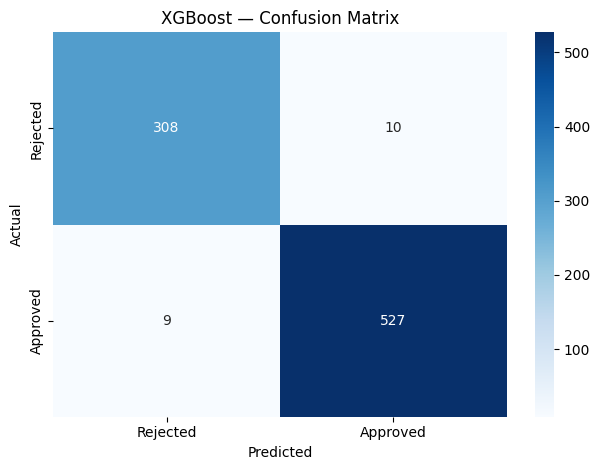

In [34]:
# Classification Report + Confusion Matrix
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Rejected", "Approved"],
            yticklabels=["Rejected", "Approved"])
plt.title("XGBoost — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

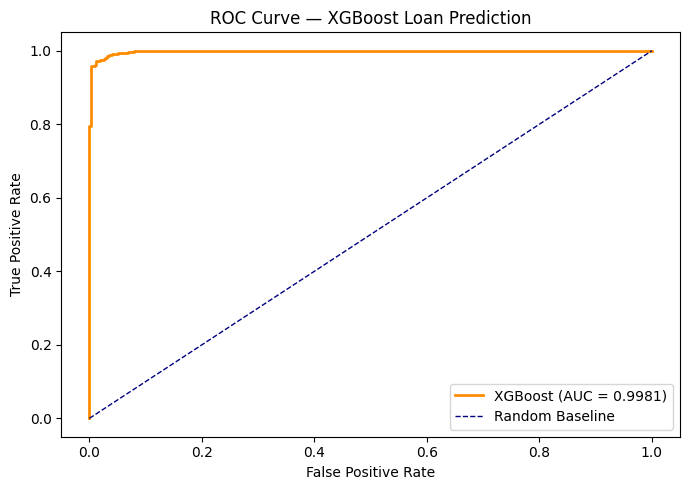

In [35]:
# ROC Curve 
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"XGBoost (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], "navy", lw=1, linestyle="--",
         label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost Loan Prediction")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

              Model  Accuracy
Logistic Regression    0.8197
      Random Forest    0.9801
            XGBoost    0.9778


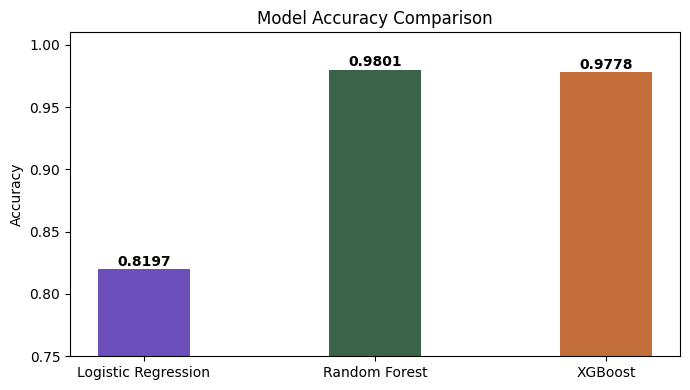

In [36]:
# Model Comparison
# Comparing against group's results
comparison = pd.DataFrame({
    "Model"   : ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.8197, 0.9801, round(accuracy_score(y_test, y_pred), 4)]
})
print(comparison.to_string(index=False))

plt.figure(figsize=(7, 4))
colors = ["#6b4fbb", "#3a6349", "#c46e3a"]
plt.bar(comparison["Model"], comparison["Accuracy"], color=colors, width=0.4)
plt.ylim(0.75, 1.01)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
for i, v in enumerate(comparison["Accuracy"]):
    plt.text(i, v + 0.003, f"{v:.4f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [37]:
# SHAP Setup
explainer   = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

print("SHAP values computed")
print("Shape:", shap_values.values.shape)

SHAP values computed
Shape: (854, 11)


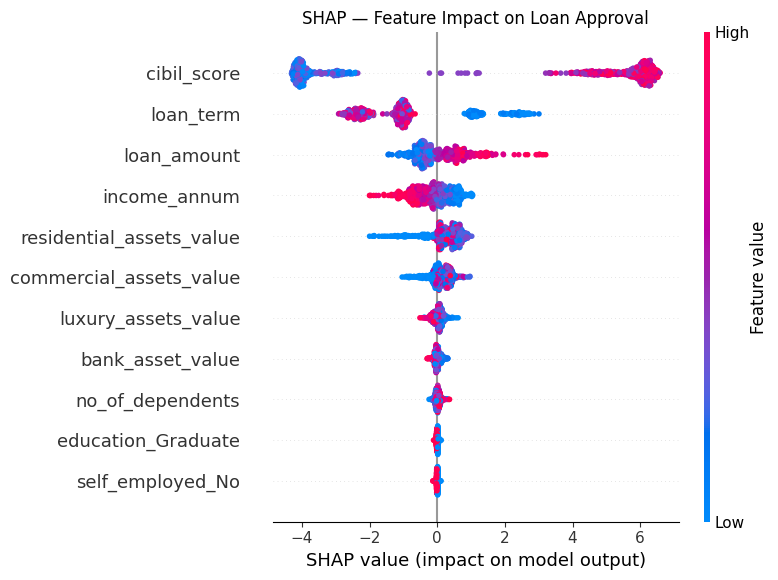

In [38]:
# SHAP Summary Plot 
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP — Feature Impact on Loan Approval")
plt.tight_layout()
plt.show()

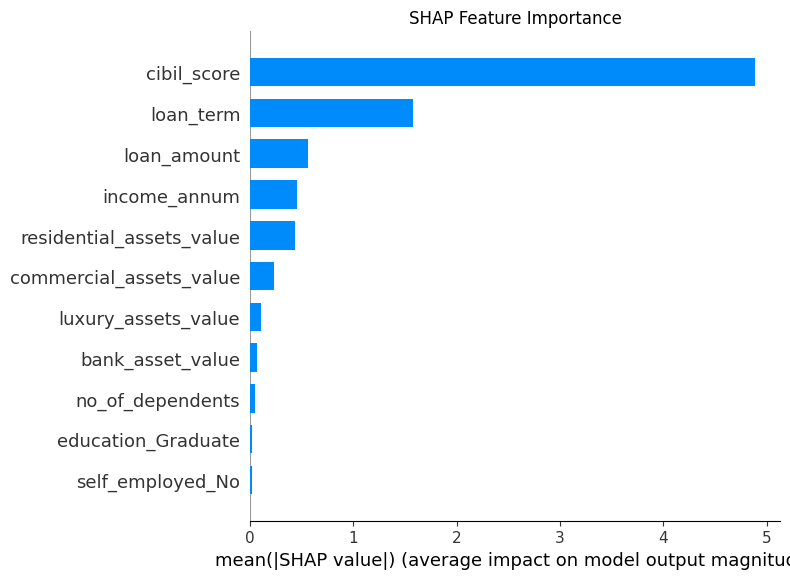

In [39]:
# SHAP Bar Plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

Applicant #0
Actual    : Rejected
Predicted : Rejected


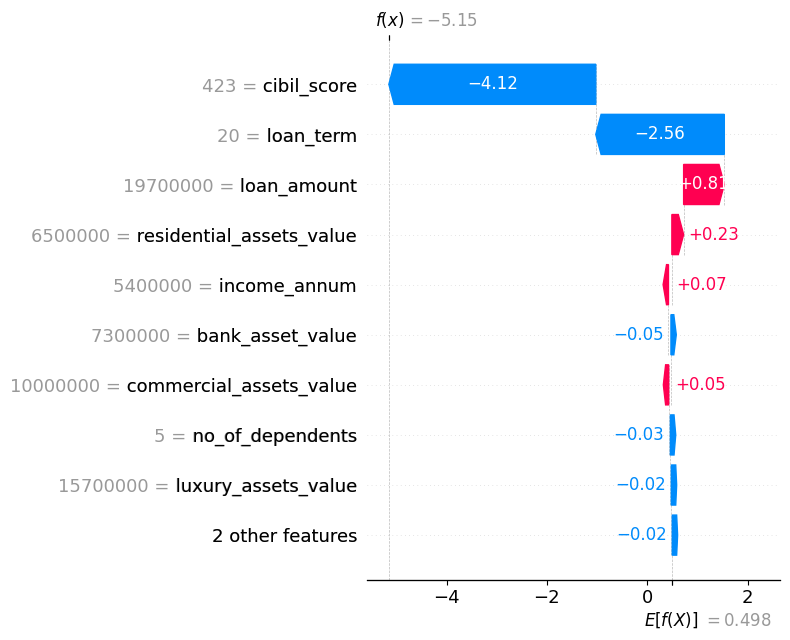

In [40]:
# SHAP Waterfall — Explain One Applicant 
sample_idx = 0

print(f"Applicant #{sample_idx}")
print(f"Actual    : {'Approved' if y_test.iloc[sample_idx] else 'Rejected'}")
print(f"Predicted : {'Approved' if y_pred[sample_idx] else 'Rejected'}")

shap.plots.waterfall(shap_values[sample_idx], show=False)
plt.tight_layout()
plt.show()

In [41]:
import pickle

# Save the trained model
with open("xgb_loan_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Save feature column names so Flask uses exact same order
with open("feature_names.pkl", "wb") as f:
    pickle.dump(list(X_train.columns), f)

print("✅ Model saved successfully")
print("Features:", list(X_train.columns))

✅ Model saved successfully
Features: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'education_Graduate', 'self_employed_No']


In [42]:
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Random Forest
rf_acc   = accuracy_score(y_test, rf.predict(X_test))
rf_auc   = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

# XGBoost
xgb_acc  = accuracy_score(y_test, xgb_model.predict(X_test))
xgb_auc  = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])

print(f"Random Forest — Accuracy: {rf_acc:.4f} | AUC: {rf_auc:.4f}")
print(f"XGBoost       — Accuracy: {xgb_acc:.4f} | AUC: {xgb_auc:.4f}")

Random Forest — Accuracy: 0.9789 | AUC: 0.9987
XGBoost       — Accuracy: 0.9778 | AUC: 0.9981


In [43]:
import pickle

# Save Random Forest model
with open("rf_loan_model.pkl", "wb") as f:
    pickle.dump(rf, f)

# Save feature names
with open("feature_names.pkl", "wb") as f:
    pickle.dump(list(X_train.columns), f)

print("✅ Random Forest model saved")
print("✅ Features:", list(X_train.columns))

✅ Random Forest model saved
✅ Features: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'education_Graduate', 'self_employed_No']


In [44]:
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)

# ── All key metrics in one place ──────────────────────────────────────────────
rf_pred      = rf.predict(X_test)
rf_pred_prob = rf.predict_proba(X_test)[:, 1]

print("=" * 50)
print("   RANDOM FOREST — MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(f"  Accuracy  : {accuracy_score(y_test, rf_pred):.4f}  ({accuracy_score(y_test, rf_pred)*100:.2f}%)")
print(f"  ROC-AUC   : {roc_auc_score(y_test, rf_pred_prob):.4f}")
print(f"  Precision : {precision_score(y_test, rf_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, rf_pred):.4f}")
print(f"  F1 Score  : {f1_score(y_test, rf_pred):.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, rf_pred,
      target_names=["Rejected", "Approved"]))

   RANDOM FOREST — MODEL PERFORMANCE SUMMARY
  Accuracy  : 0.9789  (97.89%)
  ROC-AUC   : 0.9987
  Precision : 0.9761
  Recall    : 0.9907
  F1 Score  : 0.9833

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.98      0.96      0.97       318
    Approved       0.98      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



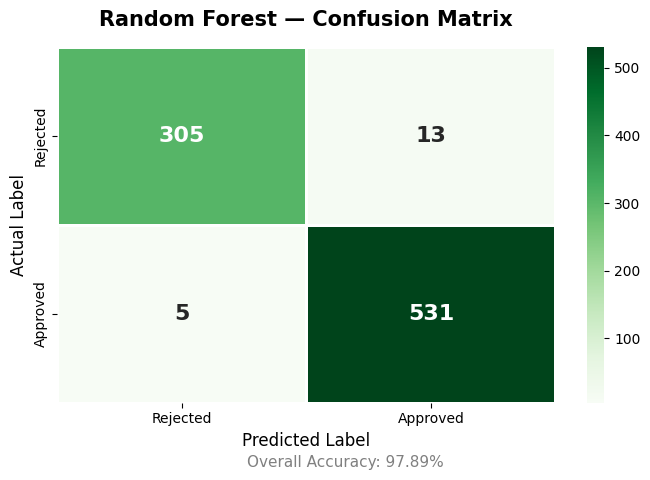

Saved: rf_confusion_matrix.png


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Rejected", "Approved"],
            yticklabels=["Rejected", "Approved"],
            linewidths=1, linecolor="white",
            annot_kws={"size": 16, "weight": "bold"})

plt.title("Random Forest — Confusion Matrix", fontsize=15, fontweight="bold", pad=15)
plt.ylabel("Actual Label",    fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)

# Add accuracy text
total   = cm.sum()
correct = cm[0,0] + cm[1,1]
plt.suptitle(f"Overall Accuracy: {correct/total*100:.2f}%",
             fontsize=11, color="gray", y=0.02)

plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_confusion_matrix.png")

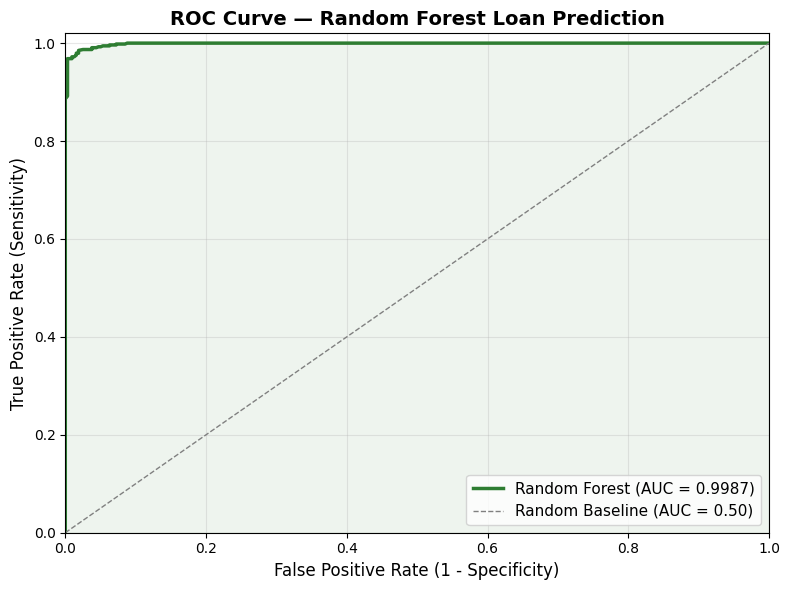

AUC Score: 0.9987
Saved: rf_roc_curve.png


In [46]:
fpr, tpr, thresholds = roc_curve(y_test, rf_pred_prob)
auc_score = roc_auc_score(y_test, rf_pred_prob)

plt.figure(figsize=(8, 6))

# ROC curve
plt.plot(fpr, tpr, color="#2e7d32", lw=2.5,
         label=f"Random Forest (AUC = {auc_score:.4f})")

# Baseline
plt.plot([0, 1], [0, 1], color="gray", lw=1,
         linestyle="--", label="Random Baseline (AUC = 0.50)")

# Shade area under curve
plt.fill_between(fpr, tpr, alpha=0.08, color="#2e7d32")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity)",      fontsize=12)
plt.title("ROC Curve — Random Forest Loan Prediction",
          fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("rf_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"AUC Score: {auc_score:.4f}")
print("Saved: rf_roc_curve.png")

Top Features by Importance:
                 Feature  Importance
             cibil_score    0.813940
               loan_term    0.060698
             loan_amount    0.030946
     luxury_assets_value    0.018123
            income_annum    0.017831
residential_assets_value    0.017130
 commercial_assets_value    0.014782
        bank_asset_value    0.013749
        no_of_dependents    0.007979
        self_employed_No    0.002473
      education_Graduate    0.002347


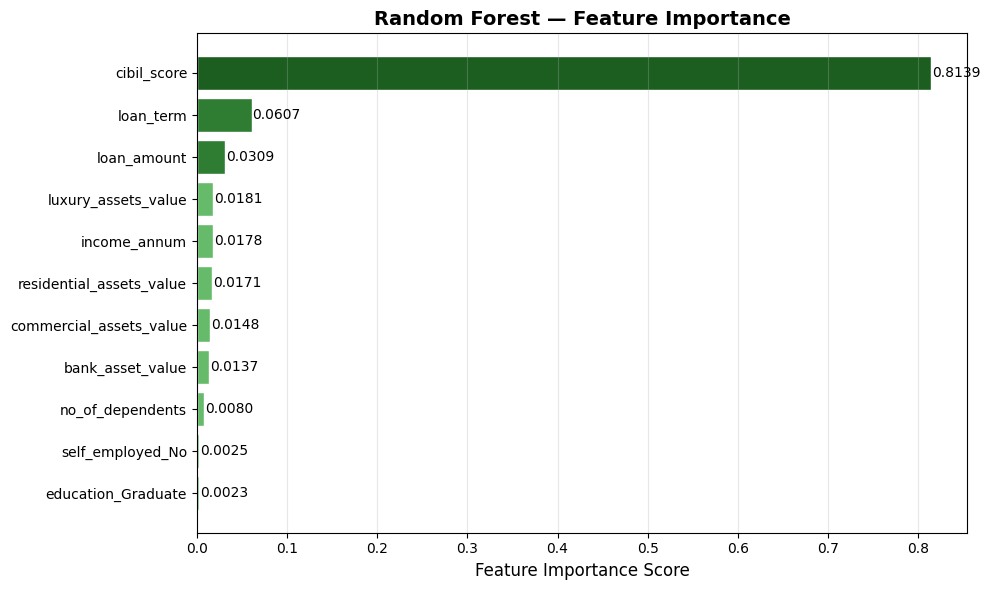

Saved: rf_feature_importance.png


In [47]:
import pandas as pd

# Get feature importances
importances = rf.feature_importances_
feat_df     = pd.DataFrame({
    "Feature"   : X_train.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top Features by Importance:")
print(feat_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
colors = ["#1b5e20" if i == 0 else "#2e7d32" if i < 3 else "#66bb6a"
          for i in range(len(feat_df))]

bars = plt.barh(feat_df["Feature"][::-1],
                feat_df["Importance"][::-1],
                color=colors[::-1], edgecolor="white")

# Add value labels
for bar, val in zip(bars, feat_df["Importance"][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=10)

plt.xlabel("Feature Importance Score", fontsize=12)
plt.title("Random Forest — Feature Importance",
          fontsize=14, fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_feature_importance.png")

In [48]:
import shap

# SHAP explainer for Random Forest
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# For binary classification shap_values is a list [class0, class1]
# class 1 (Approved) = shap_values[1]
print("SHAP values computed successfully")
print(f"Shape: {shap_values[1].shape}")

SHAP values computed successfully
Shape: (11, 2)


In [49]:
import shap

# Check exact shapes first
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

print("Type of shap_values        :", type(shap_values))
print("X_test shape               :", X_test.shape)

if isinstance(shap_values, list):
    print("Number of classes          :", len(shap_values))
    for i, sv in enumerate(shap_values):
        print(f"shap_values[{i}] shape      :", sv.shape)
else:
    print("shap_values shape          :", shap_values.shape)

Type of shap_values        : <class 'numpy.ndarray'>
X_test shape               : (854, 11)
shap_values shape          : (854, 11, 2)


X_test shape  : (854, 11)
sv shape      : (854, 11)
Shapes match  : True


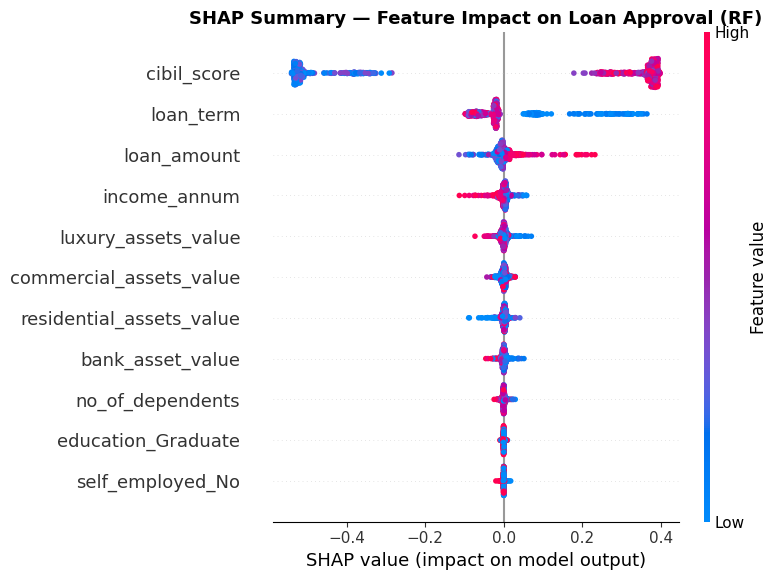

Saved: rf_shap_summary.png


In [50]:
import shap
import numpy as np

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Handle both old and new shap versions
if isinstance(shap_values, list):
    # Old shap version — list of arrays per class
    sv = shap_values[1]
else:
    # New shap version — single 3D array
    sv = shap_values[:, :, 1]

# Trim to match X_test columns if needed
if sv.shape[1] != X_test.shape[1]:
    sv = sv[:, :X_test.shape[1]]

print("X_test shape  :", X_test.shape)
print("sv shape      :", sv.shape)
print("Shapes match  :", sv.shape[1] == X_test.shape[1])

# SHAP Summary Plot
plt.figure()
shap.summary_plot(sv, X_test,
                  plot_type="dot",
                  show=False)
plt.title("SHAP Summary — Feature Impact on Loan Approval (RF)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("rf_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_shap_summary.png")

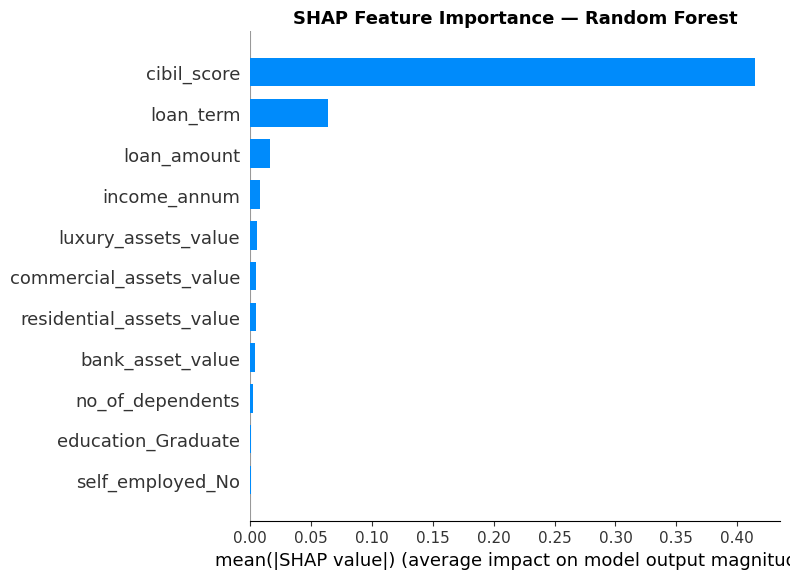

Saved: rf_shap_bar.png


In [51]:
# SHAP Bar Plot 
plt.figure()
shap.summary_plot(sv, X_test,
                  plot_type="bar",
                  show=False)
plt.title("SHAP Feature Importance — Random Forest",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("rf_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_shap_bar.png")

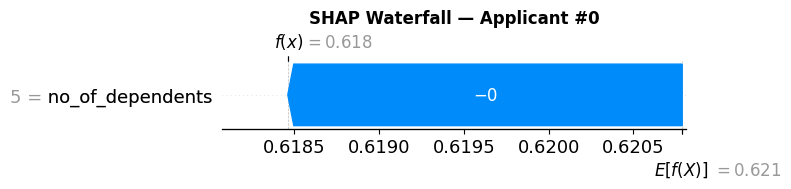

Saved: rf_shap_waterfall.png


In [52]:
# SHAP Waterfall — Alternative using force plot 
sample_idx = 0

explainer2   = shap.TreeExplainer(rf)
shap_vals2   = explainer2.shap_values(X_test)

# shap_vals2 is a list [class0_array, class1_array]
# Use class 1 = Approved, trim last column
sv_single = shap_vals2[1][sample_idx, :-1] \
            if shap_vals2[1].shape[1] != X_test.shape[1] \
            else shap_vals2[1][sample_idx]

explanation = shap.Explanation(
    values        = sv_single,
    base_values   = float(explainer2.expected_value[1]),
    data          = X_test.iloc[sample_idx].values,
    feature_names = list(X_test.columns)
)

shap.plots.waterfall(explanation, show=False)
plt.title(f"SHAP Waterfall — Applicant #{sample_idx}",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("rf_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_shap_waterfall.png")

Applicant #0
  Actual    : Rejected
  Predicted : Rejected
  Approved Probability: 0.0%


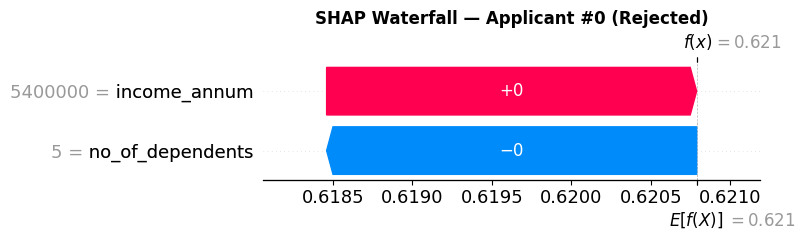

Saved: rf_shap_waterfall.png


In [53]:
# Explain a single applicant prediction
sample_idx = 0

actual    = "Approved" if y_test.iloc[sample_idx] == 1 else "Rejected"
predicted = "Approved" if rf_pred[sample_idx]     == 1 else "Rejected"

print(f"Applicant #{sample_idx}")
print(f"  Actual    : {actual}")
print(f"  Predicted : {predicted}")
print(f"  Approved Probability: {rf_pred_prob[sample_idx]*100:.1f}%")

# Waterfall using shap Explanation object
explanation = shap.Explanation(
    values    = shap_values[1][sample_idx],
    base_values = explainer.expected_value[1],
    data      = X_test.iloc[sample_idx],
    feature_names = list(X_test.columns)
)

shap.plots.waterfall(explanation, show=False)
plt.title(f"SHAP Waterfall — Applicant #{sample_idx} ({predicted})",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("rf_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_shap_waterfall.png")

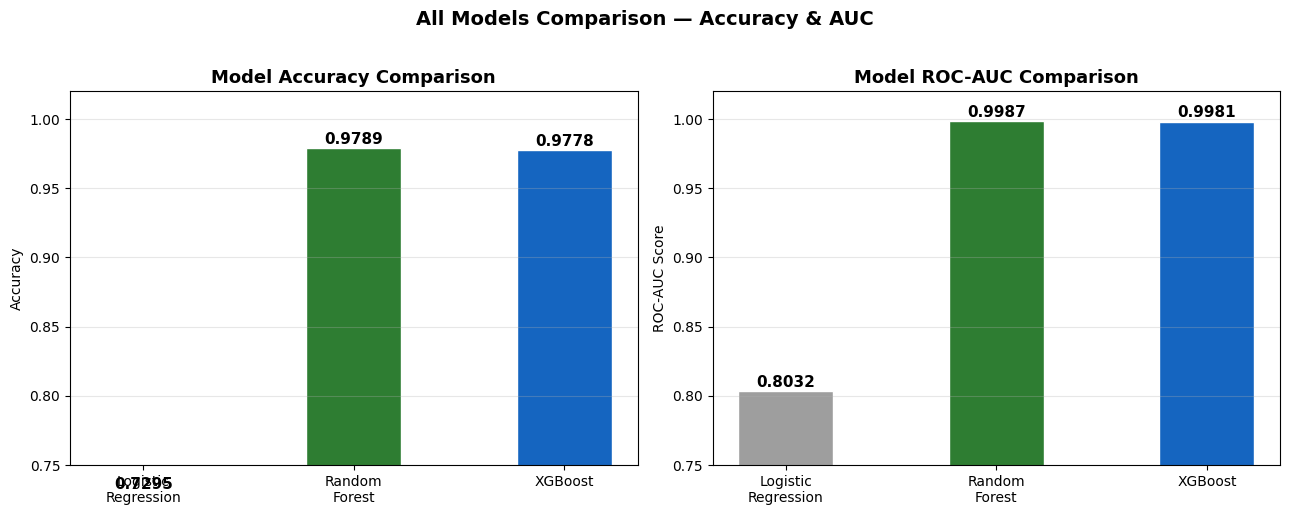

Saved: model_comparison.png


In [54]:
# Final Model Comparison — Accuracy & AUC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

lg = LogisticRegression()
lg.fit(X_train, y_train)

lg_acc  = accuracy_score(y_test, lg.predict(X_test))
rf_acc  = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test))

lg_auc  = roc_auc_score(y_test, lg.predict_proba(X_test)[:,1])
rf_auc  = roc_auc_score(y_test, rf_pred_prob)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])

models   = ["Logistic\nRegression", "Random\nForest", "XGBoost"]
accuracy = [lg_acc,  rf_acc,  xgb_acc]
auc      = [lg_auc,  rf_auc,  xgb_auc]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy
colors_acc = ["#9e9e9e", "#2e7d32", "#1565c0"]
bars1 = axes[0].bar(models, accuracy, color=colors_acc,
                    width=0.45, edgecolor="white")
axes[0].set_ylim(0.75, 1.02)
axes[0].set_title("Model Accuracy Comparison",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Accuracy")
axes[0].grid(axis="y", alpha=0.3)
for bar, val in zip(bars1, accuracy):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.003, f"{val:.4f}",
                 ha="center", fontweight="bold", fontsize=11)

# AUC
colors_auc = ["#9e9e9e", "#2e7d32", "#1565c0"]
bars2 = axes[1].bar(models, auc, color=colors_auc,
                    width=0.45, edgecolor="white")
axes[1].set_ylim(0.75, 1.02)
axes[1].set_title("Model ROC-AUC Comparison",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel("ROC-AUC Score")
axes[1].grid(axis="y", alpha=0.3)
for bar, val in zip(bars2, auc):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 0.003, f"{val:.4f}",
                 ha="center", fontweight="bold", fontsize=11)

plt.suptitle("All Models Comparison — Accuracy & AUC",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")

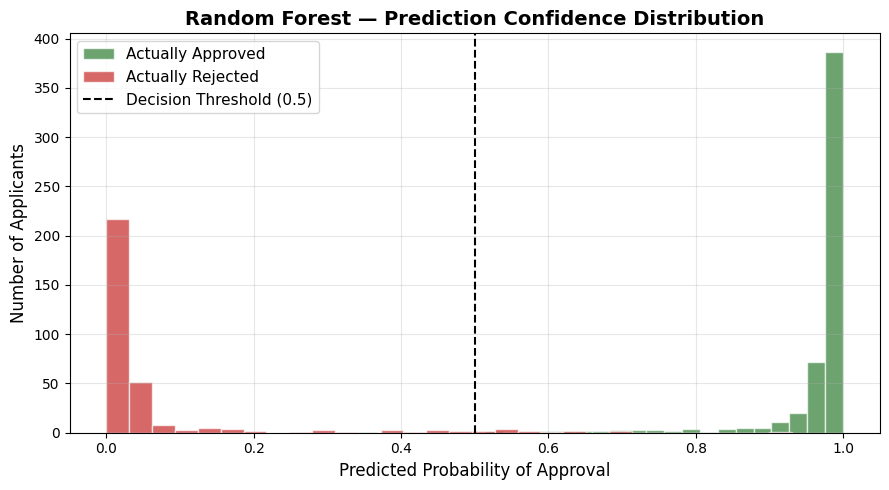

Saved: rf_prediction_distribution.png


In [55]:
# Shows how confident the model is across all test predictions
plt.figure(figsize=(9, 5))

approved_probs = rf_pred_prob[y_test == 1]
rejected_probs = rf_pred_prob[y_test == 0]

plt.hist(approved_probs, bins=30, alpha=0.7,
         color="#2e7d32", label="Actually Approved", edgecolor="white")
plt.hist(rejected_probs, bins=30, alpha=0.7,
         color="#c62828", label="Actually Rejected",  edgecolor="white")

plt.axvline(x=0.5, color="black", linestyle="--",
            linewidth=1.5, label="Decision Threshold (0.5)")

plt.xlabel("Predicted Probability of Approval", fontsize=12)
plt.ylabel("Number of Applicants",              fontsize=12)
plt.title("Random Forest — Prediction Confidence Distribution",
          fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rf_prediction_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_prediction_distribution.png")

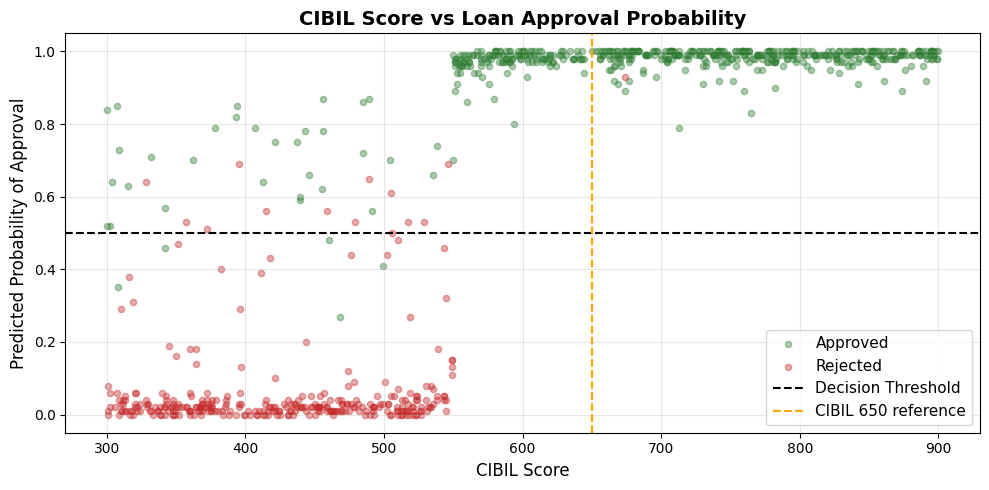

Saved: cibil_vs_approval.png


In [56]:
# CIBIL Score vs Predicted Approval Probability
import pandas as pd

plot_df = X_test.copy()
plot_df["Actual"]    = y_test.values
plot_df["Predicted"] = rf_pred
plot_df["Prob"]      = rf_pred_prob

plt.figure(figsize=(10, 5))

approved = plot_df[plot_df["Actual"] == 1]
rejected = plot_df[plot_df["Actual"] == 0]

plt.scatter(approved["cibil_score"], approved["Prob"],
            alpha=0.4, color="#2e7d32",
            label="Approved", s=20)
plt.scatter(rejected["cibil_score"], rejected["Prob"],
            alpha=0.4, color="#c62828",
            label="Rejected",  s=20)

plt.axhline(y=0.5, color="black", linestyle="--",
            linewidth=1.5, label="Decision Threshold")
plt.axvline(x=650, color="orange", linestyle="--",
            linewidth=1.5, label="CIBIL 650 reference")

plt.xlabel("CIBIL Score",                      fontsize=12)
plt.ylabel("Predicted Probability of Approval", fontsize=12)
plt.title("CIBIL Score vs Loan Approval Probability",
          fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("cibil_vs_approval.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cibil_vs_approval.png")